# Performance Prediction: Version 3.0

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os
import joblib

## Loading Dataset

In [2]:
df_full = pd.read_csv("../data/recalculated_performance_data.csv", delimiter=",")
df_full.head()

,employee_id,Job_Title,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,...,digital_score,hard_score,wellness_score,productivity_index,performance_score_original,composite_score,rating_label,group,department,seniority
0,c4c45a01-39e8-4561-b936-fcf185b49920,Consultant (Cloud & Infra),Bachelor's,3,3733.33,50.4,32,405,3,62,...,2.980654,2.502463,3.175713,2.780570,4,7.02,Meets expectations,pregnant,Cloud & Infra,Mid
1,51b2928a-4091-4430-97a6-50e6fea44476,Senior Consultant (Cybersecurity),Master's,2,6550.00,18.9,22,0,86,17,...,2.025195,1.539715,3.021699,1.981756,2,5.73,Partially meets,pregnant,Cybersecurity,Senior
2,01229a5b-b84d-4192-8dd3-429f7e705ba1,Junior Consultant (Cybersecurity),High School,2,2833.33,40.2,24,9,9,39,...,2.144163,1.815590,3.195668,2.190178,3,6.73,Meets expectations,pregnant,Cybersecurity,Junior
3,a04f499a-83c0-49bd-b0d9-3c8783d5fad3,Junior Consultant (Cloud & Infra),High School,2,2350.00,32.6,22,0,5,31,...,1.686067,1.589319,3.035281,1.907536,3,5.85,Partially meets,pregnant,Cloud & Infra,Junior
4,c791ec00-e86c-4e0a-b500-f75ae927521f,Consultant (Digital Transformation),Bachelor's,3,3191.67,33.5,26,0,67,33,...,3.044602,2.037041,3.189319,2.569765,4,7.35,Meets expectations,pregnant,Digital Transformation,Mid


## Exploratory Data Analysis: Feature Selection

In [3]:
df_full.describe()

,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,digital_score,hard_score,wellness_score,productivity_index,performance_score_original,composite_score
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.0,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,2.806667,4597.766673,46.827667,31.847333,376.950667,13.968667,53.462000,5.0,58.670667,2.936218,2.510277,3.331094,2.802223,3.814667,7.206753
std,0.638927,1583.059183,13.613953,7.383611,394.982389,26.676496,21.082873,0.0,5.050334,0.799089,0.638831,0.150457,0.558314,0.882896,0.835113
min,1.000000,2333.330000,14.300000,15.000000,0.000000,0.000000,0.000000,5.0,47.000000,1.000000,1.036182,2.760855,1.442654,1.000000,4.240000
25%,2.000000,3358.330000,37.200000,26.000000,0.000000,0.000000,37.750000,5.0,55.000000,2.336013,2.028551,3.209532,2.386030,3.000000,6.590000
50%,3.000000,4258.330000,47.300000,31.000000,284.500000,0.000000,53.500000,5.0,60.000000,2.918037,2.468185,3.395594,2.766688,4.000000,7.300000
75%,3.000000,5650.000000,56.125000,37.000000,630.000000,9.000000,68.000000,5.0,61.000000,3.461478,2.955496,3.447797,3.173169,4.000000,7.920000
max,4.000000,9116.670000,80.000000,50.000000,1829.000000,93.000000,100.000000,5.0,69.000000,5.000000,4.508237,3.546686,4.382499,5.000000,8.480000


In [4]:
all_cols = df_full.columns.tolist()
print(all_cols)

['employee_id', 'Job_Title', 'Education_Level', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'digital_score', 'hard_score', 'wellness_score', 'productivity_index', 'performance_score_original', 'composite_score', 'rating_label', 'group', 'department', 'seniority']


In [5]:
df_full.isna().sum()

employee_id                   0
Job_Title                     0
Education_Level               0
Performance_Score             0
Monthly_Salary                0
Work_Hours_Per_Week           0
Projects_Handled              0
Overtime_Hours                0
Sick_Days                     0
Remote_Work_Frequency         0
Team_Size                     0
Training_Hours                0
digital_score                 0
hard_score                    0
wellness_score                0
productivity_index            0
performance_score_original    0
composite_score               0
rating_label                  0
group                         0
department                    0
seniority                     0
dtype: int64

In [6]:
df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employee_id                 1500 non-null   str    
 1   Job_Title                   1500 non-null   str    
 2   Education_Level             1500 non-null   str    
 3   Performance_Score           1500 non-null   int64  
 4   Monthly_Salary              1500 non-null   float64
 5   Work_Hours_Per_Week         1500 non-null   float64
 6   Projects_Handled            1500 non-null   int64  
 7   Overtime_Hours              1500 non-null   int64  
 8   Sick_Days                   1500 non-null   int64  
 9   Remote_Work_Frequency       1500 non-null   int64  
 10  Team_Size                   1500 non-null   int64  
 11  Training_Hours              1500 non-null   int64  
 12  digital_score               1500 non-null   float64
 13  hard_score                  1500 non-null   

In [7]:
object_cols = [col for col in all_cols if df_full[col].dtype == "object"]
cardinality = {col: df_full[col].nunique() for col in object_cols}
sorted(cardinality.items(), key=lambda x: x[1])

[]

The following columns are excluded from the model:

- **employee_id**: Unique identifier with no predictive value
- **group**: Demographic group (pregnant, non_pregnant_f, male) — excluded to prevent direct bias; retained separately for the post-hoc fairness analysis
- **department**: Redundant with `Job_Title`, which already encodes the specialisation
- **seniority**: Encoded implicitly within `Job_Title` (Junior / Consultant / Senior / Managing)
- **rating_label**: Categorical string label derived directly from `Performance_Score`; including it would be pure data leakage
- **performance_score_original**: The pre-adjustment score; including it would leak information about the target construction process

In [8]:
cols_to_drop = [
    "employee_id", "group", "department", "seniority",
    "rating_label", "performance_score_original"
]

# Preserve group for fairness analysis
df_groups = df_full[["employee_id", "group"]].copy()

df = df_full.drop(columns=cols_to_drop)
df.head()

,Job_Title,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,digital_score,hard_score,wellness_score,productivity_index,composite_score
0,Consultant (Cloud & Infra),Bachelor's,3,3733.33,50.4,32,405,3,62,5,60,2.980654,2.502463,3.175713,2.780570,7.02
1,Senior Consultant (Cybersecurity),Master's,2,6550.00,18.9,22,0,86,17,5,55,2.025195,1.539715,3.021699,1.981756,5.73
2,Junior Consultant (Cybersecurity),High School,2,2833.33,40.2,24,9,9,39,5,66,2.144163,1.815590,3.195668,2.190178,6.73
3,Junior Consultant (Cloud & Infra),High School,2,2350.00,32.6,22,0,5,31,5,65,1.686067,1.589319,3.035281,1.907536,5.85
4,Consultant (Digital Transformation),Bachelor's,3,3191.67,33.5,26,0,67,33,5,61,3.044602,2.037041,3.189319,2.569765,7.35


## Exploratory Data Analysis: Checking Performance Score

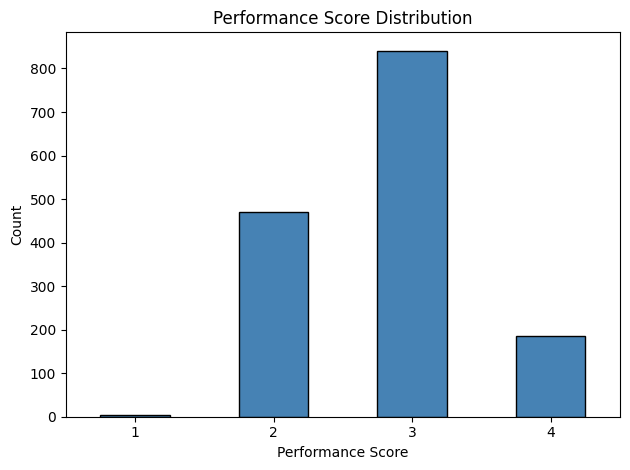

Performance_Score
1      3
2    470
3    841
4    186
Name: count, dtype: int64


In [9]:
score_counts = df["Performance_Score"].value_counts().sort_index()
score_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Performance Score")
plt.ylabel("Count")
plt.title("Performance Score Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(score_counts)

## Exploratory Data Analysis: Checking Monthly Salary w.r.t Job Title

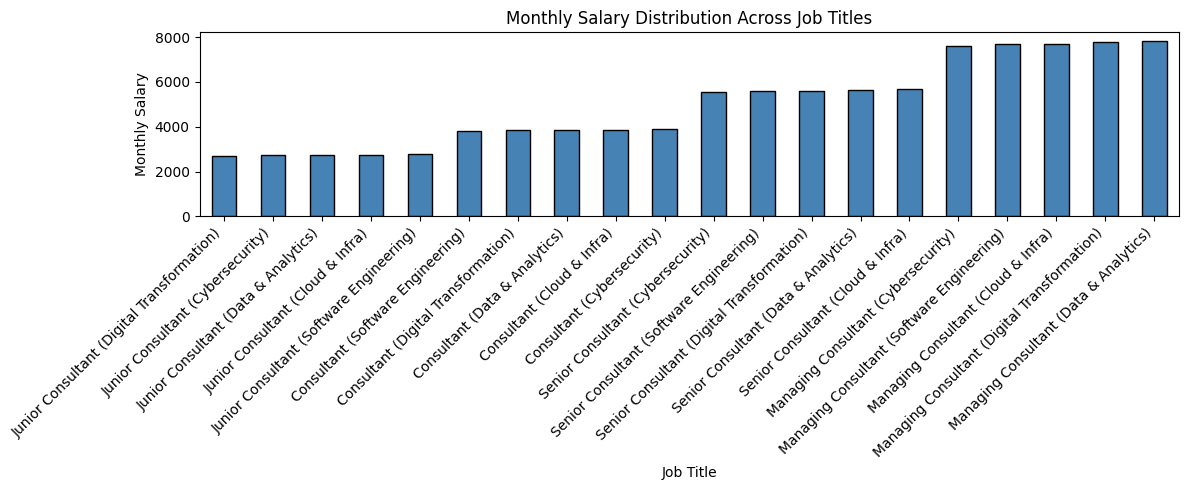

In [10]:
avg_salary_for_jobs = df.groupby("Job_Title")["Monthly_Salary"].mean().sort_values()
avg_salary_for_jobs.plot(kind="bar", color="steelblue", edgecolor="black", figsize=(12, 5))
plt.xlabel("Job Title")
plt.ylabel("Monthly Salary")
plt.title("Monthly Salary Distribution Across Job Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis: Checking Monthly Salary w.r.t Education Level

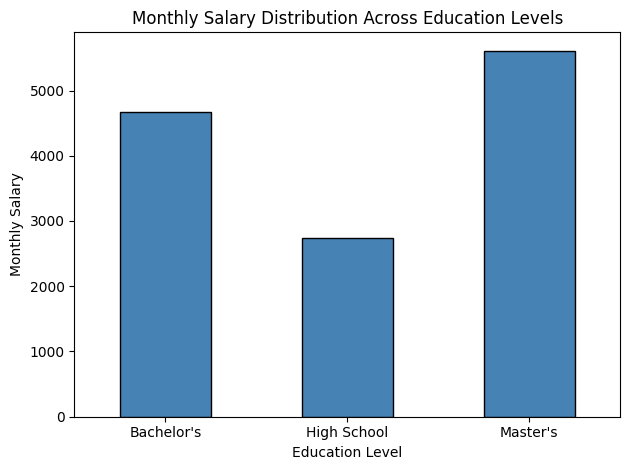

In [11]:
avg_salary_for_edu = df.groupby("Education_Level")["Monthly_Salary"].mean()
avg_salary_for_edu.plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Education Level")
plt.ylabel("Monthly Salary")
plt.title("Monthly Salary Distribution Across Education Levels")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis: Checking Feature-Target Relationship

In [12]:
target_col = "Performance_Score"
numeric_cols = [c for c in df.select_dtypes(include=["number"]).columns if c != target_col]
categorical_cols = [c for c in df.select_dtypes(include=["object"]).columns]
print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

Numeric features: ['Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'digital_score', 'hard_score', 'wellness_score', 'productivity_index', 'composite_score']
Categorical features: ['Job_Title', 'Education_Level']


C:\Users\Skell\AppData\Local\Temp\ipykernel_12240\4161868372.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = [c for c in df.select_dtypes(include=["object"]).columns]


In [13]:
df[numeric_cols + [target_col]].corr()[target_col].sort_values(ascending=False)

Performance_Score        1.000000
productivity_index       0.892561
hard_score               0.876196
digital_score            0.864004
Remote_Work_Frequency    0.854440
Work_Hours_Per_Week      0.817033
composite_score          0.805456
Projects_Handled         0.799490
Overtime_Hours           0.794884
wellness_score           0.376665
Monthly_Salary           0.346416
Sick_Days               -0.332652
Training_Hours          -0.386711
Team_Size                     NaN
Name: Performance_Score, dtype: float64

In [14]:
for col in categorical_cols:
    groups = [df[df[col] == val][target_col] for val in df[col].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"\n{col}:")
    print(f"  ANOVA p-value: {p_value:.6f}")
    if p_value < 0.05:
        print(f"  - Statistically significant at 95% confidence")
        print(df.groupby(col)[target_col].mean())
    else:
        print(f"  - Not statistically significant at 95% confidence")


Job_Title:
  ANOVA p-value: 0.000000
  - Statistically significant at 95% confidence
Job_Title
Consultant (Cloud & Infra)                      2.829268
Consultant (Cybersecurity)                      2.688406
Consultant (Data & Analytics)                   2.727273
Consultant (Digital Transformation)             2.769912
Consultant (Software Engineering)               2.711712
Junior Consultant (Cloud & Infra)               2.372881
Junior Consultant (Cybersecurity)               2.448276
Junior Consultant (Data & Analytics)            2.392157
Junior Consultant (Digital Transformation)      2.403226
Junior Consultant (Software Engineering)        2.320000
Managing Consultant (Cloud & Infra)             3.321429
Managing Consultant (Cybersecurity)             3.250000
Managing Consultant (Data & Analytics)          3.108108
Managing Consultant (Digital Transformation)    3.032258
Managing Consultant (Software Engineering)      3.289474
Senior Consultant (Cloud & Infra)               2

## Data Preprocessing: Data Splitting

In [15]:
features_col = [c for c in df.columns if c != target_col]
X = df[features_col]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1200, 15), Test: (300, 15)


## Data Preprocessing: Encoding Categorical Variables as Numeric

In [16]:
print("Education_Level unique:", X_train["Education_Level"].unique())

Education_Level unique: <StringArray>
['Bachelor's', 'Master's', 'High School']
Length: 3, dtype: str


In [17]:
# Ordinal encoding: High School < Bachelor's < Master's
ordinal_cols = ["Education_Level"]
education_order = [["High School", "Bachelor’s", "Master’s"]]

In [18]:
print("Job_Title unique:", X_train["Job_Title"].unique())

Job_Title unique: <StringArray>
[                  'Consultant (Cloud & Infra)',
   'Senior Consultant (Digital Transformation)',
 'Managing Consultant (Digital Transformation)',
          'Managing Consultant (Cloud & Infra)',
                'Consultant (Data & Analytics)',
            'Junior Consultant (Cloud & Infra)',
     'Senior Consultant (Software Engineering)',
            'Junior Consultant (Cybersecurity)',
            'Consultant (Software Engineering)',
   'Junior Consultant (Digital Transformation)',
         'Junior Consultant (Data & Analytics)',
       'Managing Consultant (Data & Analytics)',
                   'Consultant (Cybersecurity)',
         'Senior Consultant (Data & Analytics)',
            'Senior Consultant (Cloud & Infra)',
            'Senior Consultant (Cybersecurity)',
          'Consultant (Digital Transformation)',
          'Managing Consultant (Cybersecurity)',
   'Managing Consultant (Software Engineering)',
     'Junior Consultant (Software Eng

In [19]:
# One-hot encoding for Job_Title (no natural order between roles)
onehot_cols = ["Job_Title"]

In [20]:
# LabelEncoder maps Performance_Score 1–4 → 0–3
label_encoder = LabelEncoder()
label_y_train = label_encoder.fit_transform(y_train)
label_y_test  = label_encoder.transform(y_test)
print("Classes:", label_encoder.classes_)

Classes: [1 2 3 4]


## Data Preprocessing: Creating a Column Transformer

In [21]:
# In Cell 21, update the ordinal transformer:
ordinal_transformer = OrdinalEncoder(categories=[['High School', "Bachelor's", "Master's"]])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('ordinal', ordinal_transformer, ["Education_Level"]), # Use straight apostrophes here
        ('onehot', OneHotEncoder(drop='first', handle_unknown='error'), onehot_cols)
    ],
    remainder='passthrough'
)

## Model: Selection Rationale

Five models are selected for performance prediction:

1. **Logistic Regression**: Baseline linear model with interpretable coefficients.
2. **Ridge Classifier**: L2-regularised linear classifier; robust to multicollinearity.
3. **Random Forest Classifier**: Ensemble of trees; handles feature interactions and provides feature importance.
4. **Gradient Boosting Classifier**: Sequential boosting; captures complex non-linear relationships.
5. **XGBoost Classifier**: Optimised gradient boosting with regularisation; well-suited for tabular multiclass tasks.

In [22]:
n_classes = len(label_encoder.classes_)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Ridge Classifier":    RidgeClassifier(alpha=1.0, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(
                               n_estimators=100, random_state=42, n_jobs=-1,
                               objective="multi:softprob",
                               num_class=n_classes,
                               eval_metric="mlogloss"
                           ),
}

## Model: Cross-Validation

In [23]:
cv_results = {}

for name, model in models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
    cv_scores = cross_val_score(pipeline, X_train, label_y_train, cv=5, scoring="accuracy", n_jobs=-1)
    cv_results[name] = {"mean_cv_score": cv_scores.mean(), "std_cv_score": cv_scores.std(), "cv_scores": cv_scores}
    print(f"{name}: mean accuracy = {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

c:\preganantDefinitivo\venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Logistic Regression: mean accuracy = 0.9817 (+/- 0.0145)


c:\preganantDefinitivo\venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Ridge Classifier: mean accuracy = 0.8600 (+/- 0.0449)


c:\preganantDefinitivo\venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Random Forest: mean accuracy = 0.9967 (+/- 0.0033)


c:\preganantDefinitivo\venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Gradient Boosting: mean accuracy = 1.0000 (+/- 0.0000)


c:\preganantDefinitivo\venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


XGBoost: mean accuracy = 0.9967 (+/- 0.0062)


## Model: Training & Evaluation

In [24]:
cv_comparison = pd.DataFrame({
    name: {"Mean CV Accuracy": cv_results[name]["mean_cv_score"],
           "Std CV Accuracy":  cv_results[name]["std_cv_score"]}
    for name in cv_results
}).T
cv_comparison

,Mean CV Accuracy,Std CV Accuracy
Logistic Regression,0.981667,0.007265
Ridge Classifier,0.860000,0.022454
Random Forest,0.996667,0.001667
Gradient Boosting,1.000000,0.000000
XGBoost,0.996667,0.003118


In [25]:
best_model_name = cv_comparison.sort_values("Mean CV Accuracy", ascending=False).index[0]
best_model      = models[best_model_name]
print(f"Selected model: {best_model_name}")
print(f"Mean CV accuracy (5-fold): {cv_comparison.loc[best_model_name, 'Mean CV Accuracy']:.4f}")

Selected model: Gradient Boosting
Mean CV accuracy (5-fold): 1.0000


In [26]:
best_pipeline = Pipeline([("preprocessor", preprocessor), ("model", best_model)])
best_pipeline.fit(X_train, label_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

Accuracy: 1.0000

Classification Report:
                    precision    recall  f1-score   support

     Does Not Meet       1.00      1.00      1.00         1
   Partially Meets       1.00      1.00      1.00        94
Meets Expectations       1.00      1.00      1.00       168
           Exceeds       1.00      1.00      1.00        37

          accuracy                           1.00       300
         macro avg       1.00      1.00      1.00       300
      weighted avg       1.00      1.00      1.00       300



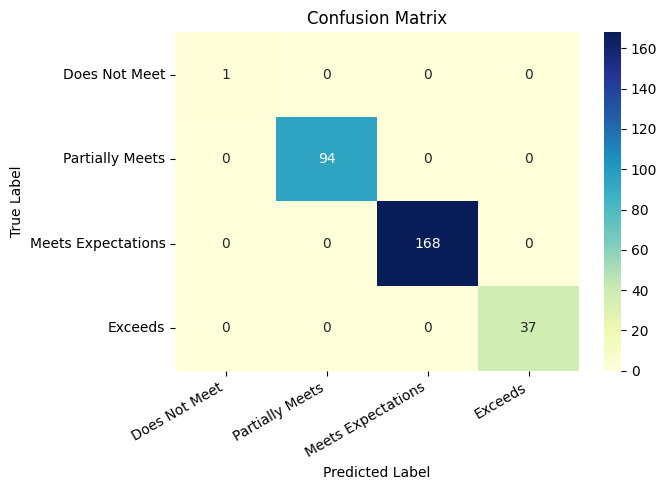

In [27]:
# Map encoded classes back to readable labels
class_names_map = {1: "Does Not Meet", 2: "Partially Meets", 3: "Meets Expectations", 4: "Exceeds"}
class_names = [class_names_map.get(c, str(c)) for c in label_encoder.classes_]

label_y_test_pred_encoded = best_pipeline.predict(X_test)
y_test_pred = label_encoder.inverse_transform(label_y_test_pred_encoded)

print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=30, ha="right")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Saving Model & Preprocessing Objects

In [28]:
os.makedirs("../models", exist_ok=True)
joblib.dump(best_pipeline, "../models/performance_prediction_model.pkl")
print("Performance model saved.")

Performance model saved.


In [29]:
os.makedirs("../preprocessors", exist_ok=True)
joblib.dump(label_encoder, "../preprocessors/label_encoder.pkl")

os.makedirs("../data/processed", exist_ok=True)
feature_info = {
    "categorical_cols": categorical_cols,
    "numeric_cols":     numeric_cols,
    "onehot_cols":      onehot_cols,
    "ordinal_cols":     ordinal_cols,
    "all_features":     features_col,
}
joblib.dump(feature_info, "../data/processed/performance_feature_info.pkl")
print("Preprocessing objects saved.")

Preprocessing objects saved.


## Fairness Analysis: Predicted Performance Across Groups

This section evaluates whether the trained model produces systematically different predictions for the three demographic groups (**pregnant**, **non_pregnant_f**, **male**).

The `group` column was deliberately excluded from model training to prevent it from directly influencing predictions. Here we re-attach it to the **full dataset** and compare:

1. **Mean `Performance_Score`** (ground-truth adjusted target)
2. **Mean model-predicted class** (mapped back to 1–4)
3. **Mean `Monthly_Salary`** (monetary variable)
4. **Mean `productivity_index`** (composite productivity metric)

A fair model should show no meaningful difference in average predicted scores across groups when the underlying feature profiles are comparable.

In [30]:
# Re-attach group to the full feature set (group was never in X)
df_bias = df_full.copy()

X_all = df_full[features_col]
pred_encoded_all = best_pipeline.predict(X_all)
pred_class_all   = label_encoder.inverse_transform(pred_encoded_all)   # back to 1–4

df_bias["predicted_perf_class"] = pred_class_all.astype(float)
print(df_bias.groupby("group")["predicted_perf_class"].value_counts().sort_index())

group           predicted_perf_class
male            2.0                      90
                3.0                     323
                4.0                      87
non_pregnant_f  2.0                     120
                3.0                     295
                4.0                      85
pregnant        1.0                       3
                2.0                     260
                3.0                     223
                4.0                      14
Name: count, dtype: int64


In [31]:
group_perf = df_bias.groupby("group").agg(
    n                         = ("group",                "count"),
    mean_actual_perf_score    = ("Performance_Score",    "mean"),
    mean_predicted_perf_score = ("predicted_perf_class", "mean"),
    mean_monthly_salary       = ("Monthly_Salary",       "mean"),
    mean_productivity_index   = ("productivity_index",   "mean"),
).round(4)

print("Performance, Salary & Productivity by Group:")
print(group_perf.to_string())

Performance, Salary & Productivity by Group:
                  n  mean_actual_perf_score  mean_predicted_perf_score  mean_monthly_salary  mean_productivity_index
group                                                                                                               
male            500                   2.994                      2.994            4649.0167                   2.9896
non_pregnant_f  500                   2.930                      2.930            4632.2333                   2.9254
pregnant        500                   2.496                      2.496            4512.0500                   2.4916


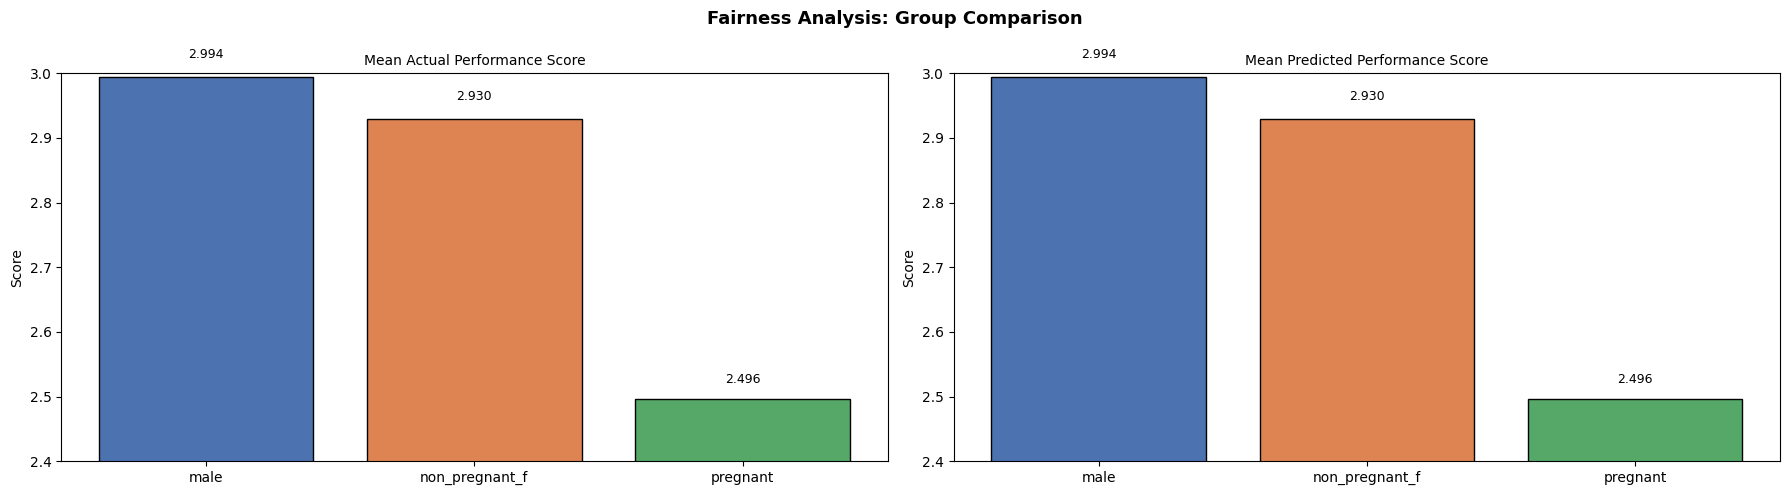

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
groups     = group_perf.index.tolist()
bar_colors = ["#4C72B0", "#DD8452", "#55A868"]

metrics = [
    ("mean_actual_perf_score",    "Mean Actual Performance Score",   "Score",      (2.4, 3)),
    ("mean_predicted_perf_score", "Mean Predicted Performance Score","Score",      (2.4, 3)),
]

for ax, (col, title, ylabel, ylim) in zip(axes, metrics):
    vals = group_perf[col]
    ax.bar(groups, vals, color=bar_colors, edgecolor="black")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    for i, v in enumerate(vals):
        fmt = f"{v:,.0f}" if "salary" in col else f"{v:.3f}"
        ax.text(i, v * 1.01, fmt, ha="center", fontsize=9)

plt.suptitle("Fairness Analysis: Group Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [33]:
from scipy.stats import f_oneway

cols_to_test = {
    "Performance_Score (actual)":    "Performance_Score",
    "Predicted Performance Score":   "predicted_perf_class",
    "Monthly_Salary":                "Monthly_Salary",
    "productivity_index":            "productivity_index",
}

print("ANOVA Results (H0: all group means are equal):")
for label, col in cols_to_test.items():
    group_arrays = [df_bias[df_bias["group"] == g][col].values for g in groups]
    f_val, p_val = f_oneway(*group_arrays)
    sig = "→ significant ⚠" if p_val < 0.05 else "→ not significant ✓"
    print(f"  {label:<40}: F={f_val:.4f}, p={p_val:.4f}  {sig}")

ANOVA Results (H0: all group means are equal):
  Performance_Score (actual)              : F=102.0324, p=0.0000  → significant ⚠
  Predicted Performance Score             : F=102.0324, p=0.0000  → significant ⚠
  Monthly_Salary                          : F=1.1136, p=0.3286  → not significant ✓
  productivity_index                      : F=139.4572, p=0.0000  → significant ⚠


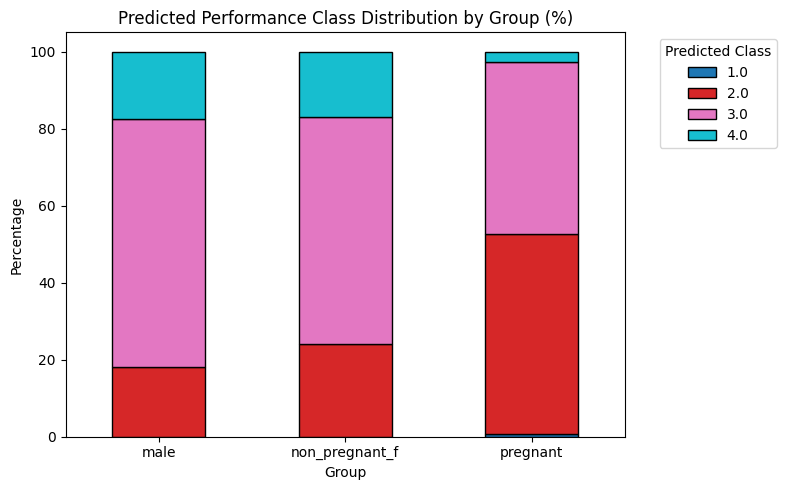

In [34]:
# Distribution of predicted classes per group (stacked bar %)
pred_dist = (
    df_bias.groupby(["group", "predicted_perf_class"])
    .size()
    .unstack(fill_value=0)
)
pred_dist_pct = pred_dist.div(pred_dist.sum(axis=1), axis=0) * 100

pred_dist_pct.plot(kind="bar", stacked=True, colormap="tab10", edgecolor="black", figsize=(8, 5))
plt.title("Predicted Performance Class Distribution by Group (%)")
plt.ylabel("Percentage")
plt.xlabel("Group")
plt.xticks(rotation=0)
plt.legend(title="Predicted Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Interpretation

- **Actual vs Predicted scores**: compare the mean actual and predicted scores per group. If the gaps are consistent across groups the model treats them equally; a larger gap for one group signals systematic under- or over-prediction.
- **Salary**: salary differences across groups reflect patterns in the *input data*, not in the model (salary is a feature here, not the target). Reported for transparency.
- **Productivity index**: shows whether observed score differences are proportional to productivity differences, or whether there is an additional unexplained component.
- **ANOVA**: a significant p-value (< 0.05) on the **predicted** score across groups indicates that model output correlates with group membership despite the group column being excluded — a signal of indirect bias through proxy features.

This notebook was updated by `La Wun Nannda`.

In [ ]:
# ============================================================
# BIAS AUDIT – V3
# ============================================================
import pandas as pd
from scipy import stats

df_full = pd.read_csv("../data/recalculated_performance_data.csv")

groups_list = ["male", "non_pregnant_f", "pregnant"]

bias_cols = {
    "Performance_Score":             "Performance_Score",
    "performance_score_original":    "performance_score_original",
    "Monthly_Salary":                "Monthly_Salary",
    "productivity_index":            "productivity_index",
    "composite_score":               "composite_score",
}

print("=== MEDIAS POR GRUPO ===")
agg = df_full.groupby("group")[
    [c for c in bias_cols.values() if c in df_full.columns]
].mean().round(4)
print(agg.to_string())

print("\n=== ANOVA POR VARIABLE (H0: todas las medias son iguales) ===")
for label, col in bias_cols.items():
    if col not in df_full.columns:
        print(f"  {label}: columna no encontrada, omitida")
        continue
    arrays = [df_full[df_full["group"] == g][col].dropna().values for g in groups_list]
    f_val, p_val = stats.f_oneway(*arrays)
    sig = "⚠  SIGNIFICATIVO – posible sesgo" if p_val < 0.05 else "✓  no significativo"
    print(f"  {label:<40}: F={f_val:.4f}, p={p_val:.6f}  → {sig}")